# SECTION 2: Huấn luyện ResNet50 cho GTSRB

Notebook này là bản hoàn chỉnh đã chỉnh theo tình trạng thực tế:

- Không copy dataset từ Google Drive sang `/content` nữa, vì bước copy quá lâu.
- Đọc trực tiếp `train.csv`, `val.csv`, `class_mapping.json` từ Section 1.
- Có `tqdm` để hiển thị tiến trình từng batch khi train/validation.
- Có `resume checkpoint` để tiếp tục train nếu bị ngắt sau một epoch.
- Lưu `resnet50_best.pth`, `resnet50_last.pth`, `history_resnet.csv/json`, `classification_report_resnet.txt`, `summary_resnet.json`.
- Dùng ResNet50 pretrained ImageNet, thay tầng `fc` cuối thành 43 lớp.


In [41]:
# ============================================================
# 1. Mount Google Drive (BỎ QUA KHI CHẠY LOCAL)
# ============================================================
# Khi chạy trên VSCode local, không cần mount Google Drive.
# Cell này được giữ lại để bảo toàn cấu trúc notebook gốc.

print("Chạy trên VSCode local - bỏ qua mount Google Drive.")

Chạy trên VSCode local - bỏ qua mount Google Drive.


In [42]:
# ============================================================
# 2. Import thư viện
# ============================================================

import os
import json
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import classification_report, accuracy_score

from tqdm.auto import tqdm


In [43]:
# ============================================================
# 3. Cấu hình chung
# ============================================================

import os
from pathlib import Path

# Tự động xác định BASE_DIR dựa trên vị trí notebook
# Notebook nằm trong notebooks/, BASE_DIR là thư mục cha
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
BASE_DIR = str(Path(NOTEBOOK_DIR).parent)

# Nếu chạy từ notebooks/ thì lùi 1 cấp
if os.path.basename(os.getcwd()) == "notebooks":
    BASE_DIR = str(Path(os.getcwd()).parent)
elif os.path.exists(os.path.join(os.getcwd(), "notebooks")):
    BASE_DIR = os.getcwd()
else:
    # Fallback: dùng thư mục hiện tại
    BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "data")
SPLITS_DIR = os.path.join(DATA_DIR, "splits")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
HISTORY_DIR = os.path.join(BASE_DIR, "history")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(SPLITS_DIR, "Train.csv")
VAL_CSV = os.path.join(SPLITS_DIR, "val.csv")
CLASS_MAPPING_PATH = os.path.join(SPLITS_DIR, "class_mapping.json")

RESNET_BEST_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_best.pth")
RESNET_LAST_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_last.pth")
RESNET_RESUME_PATH = os.path.join(CHECKPOINT_DIR, "resnet50_resume.pth")

HISTORY_JSON_PATH = os.path.join(HISTORY_DIR, "history_resnet.json")
HISTORY_CSV_PATH = os.path.join(HISTORY_DIR, "history_resnet.csv")
REPORT_TXT_PATH = os.path.join(HISTORY_DIR, "classification_report_resnet.txt")
SUMMARY_JSON_PATH = os.path.join(HISTORY_DIR, "summary_resnet.json")

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# Trên Windows local, NUM_WORKERS = 0 để tránh lỗi multiprocessing
NUM_WORKERS = 0

NUM_CLASSES = 43

EPOCHS = 15

LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Đang chạy trên CPU. Quá trình huấn luyện sẽ chậm hơn so với GPU.")

print("BASE_DIR:", BASE_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("VAL_CSV:", VAL_CSV)
print("CLASS_MAPPING_PATH:", CLASS_MAPPING_PATH)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("HISTORY_DIR:", HISTORY_DIR)

Device: cpu
Đang chạy trên CPU. Quá trình huấn luyện sẽ chậm hơn so với GPU.
BASE_DIR: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification
TRAIN_CSV: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\splits\Train.csv
VAL_CSV: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\splits\val.csv
CLASS_MAPPING_PATH: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\splits\class_mapping.json
CHECKPOINT_DIR: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\checkpoints
HISTORY_DIR: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\history


In [44]:
# ============================================================
# 4. Kiểm tra file đầu vào từ Section 1
# ============================================================

required_files = [TRAIN_CSV, VAL_CSV, CLASS_MAPPING_PATH]

for file_path in required_files:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

with open(CLASS_MAPPING_PATH, "r", encoding="utf-8") as f:
    class_mapping = json.load(f)

# --- Remap đường dẫn Colab sang local ---
COLAB_PREFIX = "/content/drive/MyDrive/Deep_Learning/data/extracted"
LOCAL_EXTRACTED_DIR = os.path.join(DATA_DIR, "extracted")

if "path" in train_df.columns:
    PATH_COL = "path"
elif "image_path" in train_df.columns:
    PATH_COL = "image_path"
else:
    raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")

train_df[PATH_COL] = train_df[PATH_COL].str.replace(
    COLAB_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).apply(os.path.normpath)

val_df[PATH_COL] = val_df[PATH_COL].str.replace(
    COLAB_PREFIX, LOCAL_EXTRACTED_DIR, regex=False
).apply(os.path.normpath)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Val columns:", val_df.columns.tolist())
print("Số class trong train:", train_df["label"].nunique())
print("Số class trong val:", val_df["label"].nunique())

print(train_df.head())

Train shape: (31367, 2)
Val shape: (7842, 2)
Train columns: ['path', 'label']
Val columns: ['path', 'label']
Số class trong train: 43
Số class trong val: 43
                                                path  label
0  c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning...     12
1  c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning...      5
2  c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning...     12
3  c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning...     13
4  c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning...     18


In [45]:
# ============================================================
# 5. Xác định cột path và kiểm tra dữ liệu
# ============================================================

def get_path_column(df):
    if "path" in df.columns:
        return "path"
    if "image_path" in df.columns:
        return "image_path"
    raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")


PATH_COL = get_path_column(train_df)

print("Cột đường dẫn ảnh:", PATH_COL)

sample_path = train_df.iloc[0][PATH_COL]
print("Ảnh mẫu:", sample_path)
print("Tồn tại:", os.path.exists(sample_path))

if not os.path.exists(sample_path):
    raise FileNotFoundError(
        "Đường dẫn ảnh trong CSV không tồn tại. "
        "Hãy kiểm tra lại train.csv/val.csv từ Section 1."
    )

Cột đường dẫn ảnh: path
Ảnh mẫu: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\extracted\Train\12\00012_00031_00018.png
Tồn tại: True


In [46]:
# ============================================================
# 6. Tạo CSV local để DataLoader sử dụng
# ============================================================
# Đường dẫn đã được remap sang local ở Cell 4.
# Lưu CSV local để các cell sau dùng.

LOCAL_TRAIN_CSV = os.path.join(SPLITS_DIR, "train_local.csv")
LOCAL_VAL_CSV = os.path.join(SPLITS_DIR, "val_local.csv")

train_df.to_csv(LOCAL_TRAIN_CSV, index=False)
val_df.to_csv(LOCAL_VAL_CSV, index=False)

print("LOCAL_TRAIN_CSV:", LOCAL_TRAIN_CSV)
print("LOCAL_VAL_CSV:", LOCAL_VAL_CSV)

# Kiểm tra ảnh local đầu tiên
local_sample_path = train_df.iloc[0][PATH_COL]
print("Ảnh local mẫu:", local_sample_path)
print("Tồn tại:", os.path.exists(local_sample_path))

LOCAL_TRAIN_CSV: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\splits\train_local.csv
LOCAL_VAL_CSV: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\splits\val_local.csv
Ảnh local mẫu: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\data\extracted\Train\12\00012_00031_00018.png
Tồn tại: True


In [47]:
# ============================================================
# 7. Transform cho ResNet50
# ============================================================
# Đồng bộ với Section 1:
# - Resize 224x224
# - Train có RandomRotation và ColorJitter
# - Normalize theo ImageNet

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [48]:
# ============================================================
# 8. Dataset đọc ảnh từ CSV
# ============================================================

class GTSRBCSVDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

        if "path" in self.data.columns:
            self.path_col = "path"
        elif "image_path" in self.data.columns:
            self.path_col = "image_path"
        else:
            raise ValueError("CSV phải có cột 'path' hoặc 'image_path'.")

        if "label" not in self.data.columns:
            raise ValueError("CSV phải có cột 'label'.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx][self.path_col]
        label = int(self.data.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [49]:
# ============================================================
# 9. Tạo Dataset và DataLoader
# ============================================================

train_set = GTSRBCSVDataset(LOCAL_TRAIN_CSV, transform=train_transform)
val_set = GTSRBCSVDataset(LOCAL_VAL_CSV, transform=val_transform)

# Khi NUM_WORKERS = 0 thì không được bật persistent_workers.
persistent_workers_flag = NUM_WORKERS > 0

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=persistent_workers_flag
)

dataset_sizes = {
    "train": len(train_set),
    "val": len(val_set)
}

print("Tổng số ảnh Train:", dataset_sizes["train"])
print("Tổng số ảnh Val:", dataset_sizes["val"])
print("Số lượng Class:", NUM_CLASSES)

# Test thời gian load 1 batch
start = time.time()
batch_images, batch_labels = next(iter(train_loader))
print("Thời gian load 1 batch:", time.time() - start, "giây")
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)


Tổng số ảnh Train: 31367
Tổng số ảnh Val: 7842
Số lượng Class: 43
Thời gian load 1 batch: 0.4987795352935791 giây
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [50]:
# ============================================================
# 10. Khởi tạo ResNet50 pretrained ImageNet
# ============================================================

model_resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Freeze backbone để train nhanh và ổn định.
# Chỉ train tầng fc mới.
for param in model_resnet.parameters():
    param.requires_grad = False

num_features = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_features, NUM_CLASSES)

model_resnet = model_resnet.to(device)

print(model_resnet.fc)

trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_resnet.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)


Linear(in_features=2048, out_features=43, bias=True)
Trainable params: 88107
Total params: 23596139


In [51]:
# ============================================================
# 11. Loss function, Optimizer và AMP scaler
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_resnet.fc.parameters(),
    lr=LEARNING_RATE
)

# Mixed precision giúp train nhanh hơn trên GPU.
# Trên CPU thì tắt AMP.
use_amp = torch.cuda.is_available()

if use_amp:
    scaler = torch.amp.GradScaler("cuda", enabled=True)
else:
    scaler = None

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Use AMP:", use_amp)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Use AMP: False


In [52]:
# ============================================================
# 12. Hàm train và validation có tqdm
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None, use_amp=False, epoch=None):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Train epoch {epoch}" if epoch is not None else "Training",
        leave=True
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=str(device).split(":")[0], enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total_samples += batch_size

        current_loss = running_loss / total_samples
        current_acc = running_corrects / total_samples

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion, device, use_amp=False, epoch=None):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    all_labels = []
    all_preds = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Val epoch {epoch}" if epoch is not None else "Validation",
        leave=True
    )

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=str(device).split(":")[0], enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            current_loss = running_loss / total_samples
            current_acc = running_corrects / total_samples

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    return epoch_loss, epoch_acc, all_labels, all_preds


In [53]:
# ============================================================
# 13. Resume checkpoint nếu có
# ============================================================

history_resnet = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time_sec": []
}

start_epoch = 1
best_val_acc = 0.0
best_epoch = 0
best_model_wts = copy.deepcopy(model_resnet.state_dict())

if os.path.exists(RESNET_RESUME_PATH):
    print("Tìm thấy resume checkpoint:", RESNET_RESUME_PATH)
    checkpoint = torch.load(RESNET_RESUME_PATH, map_location=device)

    model_resnet.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint.get("best_val_acc", 0.0)
    best_epoch = checkpoint.get("best_epoch", 0)
    history_resnet = checkpoint.get("history_resnet", history_resnet)

    best_model_wts = copy.deepcopy(model_resnet.state_dict())

    print(f"Tiếp tục train từ epoch {start_epoch}.")
    print(f"Best epoch hiện tại: {best_epoch}")
    print(f"Best val acc hiện tại: {best_val_acc:.4f}")
else:
    print("Không có resume checkpoint, train từ đầu.")


Tìm thấy resume checkpoint: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\checkpoints\resnet50_resume.pth
Tiếp tục train từ epoch 16.
Best epoch hiện tại: 12
Best val acc hiện tại: 0.8646


In [54]:
# ============================================================
# 14. Vòng lặp huấn luyện ResNet50
# ============================================================
# Có in tiến trình từng batch.
# Có lưu resume checkpoint và history sau mỗi epoch.

if start_epoch > EPOCHS:
    print(
        f"Checkpoint hiện tại đã train đến epoch {start_epoch - 1}, "
        f"lớn hơn hoặc bằng EPOCHS={EPOCHS}. Nếu muốn train tiếp, hãy tăng EPOCHS."
    )
else:
    start_training_time = time.time()

    for epoch in range(start_epoch, EPOCHS + 1):
        epoch_start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model_resnet,
            train_loader,
            criterion,
            optimizer,
            device,
            scaler=scaler,
            use_amp=use_amp,
            epoch=epoch
        )

        val_loss, val_acc, val_true, val_pred = validate_one_epoch(
            model_resnet,
            val_loader,
            criterion,
            device,
            use_amp=use_amp,
            epoch=epoch
        )

        epoch_time = time.time() - epoch_start_time

        history_resnet["epoch"].append(epoch)
        history_resnet["train_loss"].append(float(train_loss))
        history_resnet["train_acc"].append(float(train_acc))
        history_resnet["val_loss"].append(float(val_loss))
        history_resnet["val_acc"].append(float(val_acc))
        history_resnet["epoch_time_sec"].append(float(epoch_time))

        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| Time: {epoch_time:.2f}s"
        )

        # Cập nhật best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model_resnet.state_dict())

            torch.save({
                "model_name": "resnet50",
                "epoch": epoch,
                "model_state_dict": model_resnet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "num_classes": NUM_CLASSES,
                "class_mapping": class_mapping,
                "image_size": IMG_SIZE,
                "path_col": PATH_COL
            }, RESNET_BEST_PATH)

            print(f"Đã lưu best checkpoint tại epoch {epoch}: {RESNET_BEST_PATH}")

        # Lưu resume checkpoint sau mỗi epoch
        torch.save({
            "model_name": "resnet50",
            "epoch": epoch,
            "model_state_dict": model_resnet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "history_resnet": history_resnet,
            "num_classes": NUM_CLASSES,
            "class_mapping": class_mapping,
            "image_size": IMG_SIZE,
            "path_col": PATH_COL
        }, RESNET_RESUME_PATH)

        # Lưu history sau mỗi epoch
        history_df = pd.DataFrame(history_resnet)
        history_df.to_csv(HISTORY_CSV_PATH, index=False)

        with open(HISTORY_JSON_PATH, "w", encoding="utf-8") as f:
            json.dump(history_resnet, f, ensure_ascii=False, indent=4)

        print("Đã lưu resume checkpoint và history sau epoch", epoch)

    total_training_time = time.time() - start_training_time

    # Lưu last checkpoint sau khi hoàn tất
    torch.save({
        "model_name": "resnet50",
        "epoch": EPOCHS,
        "model_state_dict": model_resnet.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "last_val_acc": val_acc,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history_resnet": history_resnet,
        "num_classes": NUM_CLASSES,
        "class_mapping": class_mapping,
        "image_size": IMG_SIZE,
        "path_col": PATH_COL
    }, RESNET_LAST_PATH)

    # Load lại trọng số tốt nhất vào model hiện tại
    model_resnet.load_state_dict(best_model_wts)

    print("\nHuấn luyện hoàn tất.")
    print("Best epoch:", best_epoch)
    print("Best validation accuracy:", best_val_acc)
    print("Tổng thời gian huấn luyện phiên hiện tại:", f"{total_training_time:.2f}s")
    print("Best checkpoint:", RESNET_BEST_PATH)
    print("Resume checkpoint:", RESNET_RESUME_PATH)
    print("Last checkpoint:", RESNET_LAST_PATH)


Checkpoint hiện tại đã train đến epoch 15, lớn hơn hoặc bằng EPOCHS=15. Nếu muốn train tiếp, hãy tăng EPOCHS.


In [55]:
# ============================================================
# 15. Đọc và hiển thị history
# ============================================================

if os.path.exists(HISTORY_CSV_PATH):
    history_df = pd.read_csv(HISTORY_CSV_PATH)
else:
    history_df = pd.DataFrame(history_resnet)

print(history_df.to_string())


    epoch  train_loss  train_acc  val_loss   val_acc  epoch_time_sec
0       1    1.711973   0.564128  1.141797  0.711553      148.807205
1       2    0.978206   0.736220  0.883994  0.775822      145.432719
2       3    0.780276   0.787260  0.717519  0.803239      146.097445
3       4    0.670524   0.812956  0.652648  0.818286      143.470391
4       5    0.607255   0.824688  0.569056  0.842515      144.968559
5       6    0.558783   0.838907  0.533817  0.842260      143.238104
6       7    0.520264   0.845060  0.489081  0.854501      143.250212
7       8    0.491630   0.852807  0.496021  0.852971      143.242771
8       9    0.468872   0.858482  0.463907  0.857052      140.722703
9      10    0.450439   0.863933  0.442425  0.863173      144.351589
10     11    0.411385   0.875315  0.455603  0.862408      145.185825
11     12    0.399185   0.878599  0.437900  0.864575      143.119339
12     13    0.390243   0.879427  0.443320  0.859347      145.799392
13     14    0.344441   0.899162  

Đã lưu: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\assets\resnet_loss_curve.png


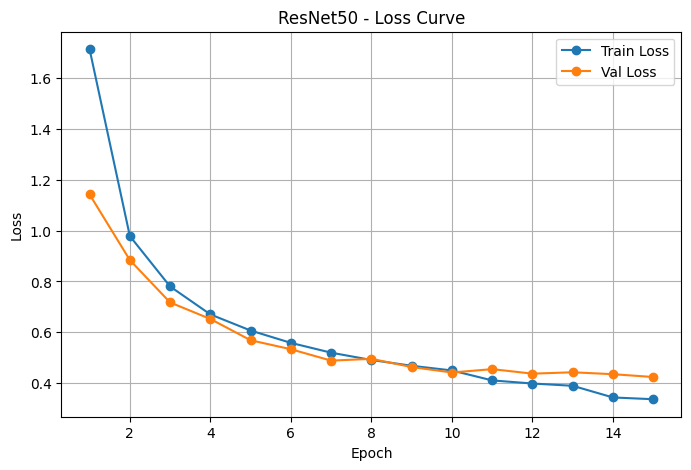

In [56]:
# ============================================================
# 16. Vẽ Loss Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Loss Curve")
plt.legend()
plt.grid(True)
os.makedirs(os.path.join(BASE_DIR, "assets"), exist_ok=True)
loss_curve_path = os.path.join(BASE_DIR, "assets", "resnet_loss_curve.png")
plt.savefig(loss_curve_path, bbox_inches='tight')
print(f"Đã lưu: {loss_curve_path}")
plt.show()


Đã lưu: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\assets\resnet_accuracy_curve.png


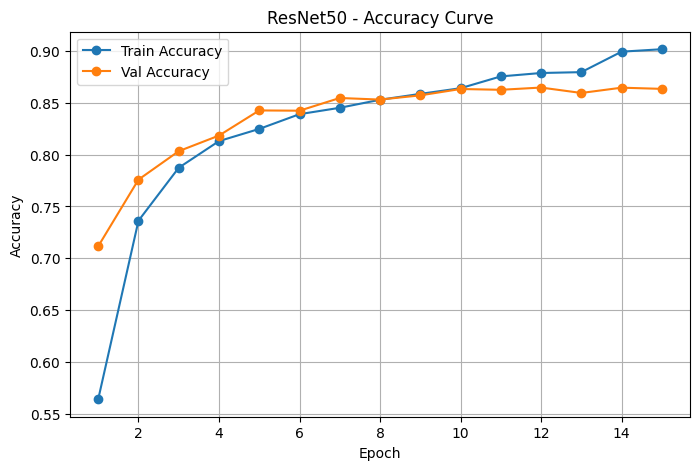

In [57]:
# ============================================================
# 17. Vẽ Accuracy Curve
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Accuracy Curve")
plt.legend()
plt.grid(True)
os.makedirs(os.path.join(BASE_DIR, "assets"), exist_ok=True)
acc_curve_path = os.path.join(BASE_DIR, "assets", "resnet_accuracy_curve.png")
plt.savefig(acc_curve_path, bbox_inches='tight')
print(f"Đã lưu: {acc_curve_path}")
plt.show()


In [58]:
# ============================================================
# 18. Load best checkpoint và đánh giá lại trên validation
# ============================================================
import os
import numpy as np
import torch

y_true_path = os.path.join(HISTORY_DIR, "resnet_y_true.npy")
y_pred_path = os.path.join(HISTORY_DIR, "resnet_y_pred.npy")

# Kiểm tra nếu đã lưu y_true và y_pred từ trước thì load thẳng lên (tiết kiệm thời gian)
if os.path.exists(y_true_path) and os.path.exists(y_pred_path):
    print("Tìm thấy kết quả dự đoán đã lưu. Đang load y_true và y_pred từ disk...")
    y_true = np.load(y_true_path)
    y_pred = np.load(y_pred_path)
    val_acc = accuracy_score(y_true, y_pred)
    print("Validation Accuracy (từ cache):", val_acc)
else:
    print("Không có cache dự đoán. Bắt đầu đánh giá toàn bộ tập validation...")
    if os.path.exists(RESNET_BEST_PATH):
        best_checkpoint = torch.load(RESNET_BEST_PATH, map_location=device)
        model_resnet.load_state_dict(best_checkpoint["model_state_dict"])
        print("Đã load best checkpoint:", RESNET_BEST_PATH)
        print("Best checkpoint epoch:", best_checkpoint.get("epoch"))
        print("Best checkpoint val acc:", best_checkpoint.get("best_val_acc"))
    else:
        print("Không tìm thấy best checkpoint, dùng model hiện tại.")

    val_loss, val_acc, y_true, y_pred = validate_one_epoch(
        model_resnet,
        val_loader,
        criterion,
        device,
        use_amp=use_amp,
        epoch="best"
    )

    print("Validation Loss:", val_loss)
    print("Validation Accuracy:", val_acc)
    print("Accuracy check:", accuracy_score(y_true, y_pred))
    
    # Lưu lại để lần sau chạy không phải đợi
    np.save(y_true_path, y_true)
    np.save(y_pred_path, y_pred)
    print("Đã lưu kết quả dự đoán vào history để dùng lại sau.")


Không có cache dự đoán. Bắt đầu đánh giá toàn bộ tập validation...
Đã load best checkpoint: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\checkpoints\resnet50_best.pth
Best checkpoint epoch: 12
Best checkpoint val acc: 0.864575363427697


Val epoch best:   0%|          | 0/246 [00:00<?, ?it/s]

Validation Loss: 0.43793927885932116
Validation Accuracy: 0.864575363427697
Accuracy check: 0.864575363427697
Đã lưu kết quả dự đoán vào history để dùng lại sau.


In [59]:
# ============================================================
# 19. Classification Report
# ============================================================

target_names = [
    str(class_mapping.get(str(i), f"Class {i}"))
    for i in range(NUM_CLASSES)
]

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report_text)

with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Đã lưu classification_report:", REPORT_TXT_PATH)


              precision    recall  f1-score   support

       00000     0.7750    0.7381    0.7561        42
       00001     0.8538    0.6577    0.7430       444
       00002     0.6622    0.7667    0.7106       450
       00003     0.8034    0.6667    0.7287       282
       00004     0.7332    0.7980    0.7642       396
       00005     0.7500    0.7742    0.7619       372
       00006     0.9873    0.9286    0.9571        84
       00007     0.7003    0.8681    0.7752       288
       00008     0.8113    0.7624    0.7861       282
       00009     0.8911    0.9184    0.9045       294
       00010     0.9160    0.9229    0.9195       402
       00011     0.9035    0.8864    0.8948       264
       00012     0.9929    0.9976    0.9952       420
       00013     0.9816    0.9884    0.9850       432
       00014     1.0000    1.0000    1.0000       156
       00015     0.9841    0.9841    0.9841       126
       00016     0.9750    0.9286    0.9512        84
       00017     0.9823    

Đã lưu confusion matrix: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\assets\confusion_matrix_resnet.png


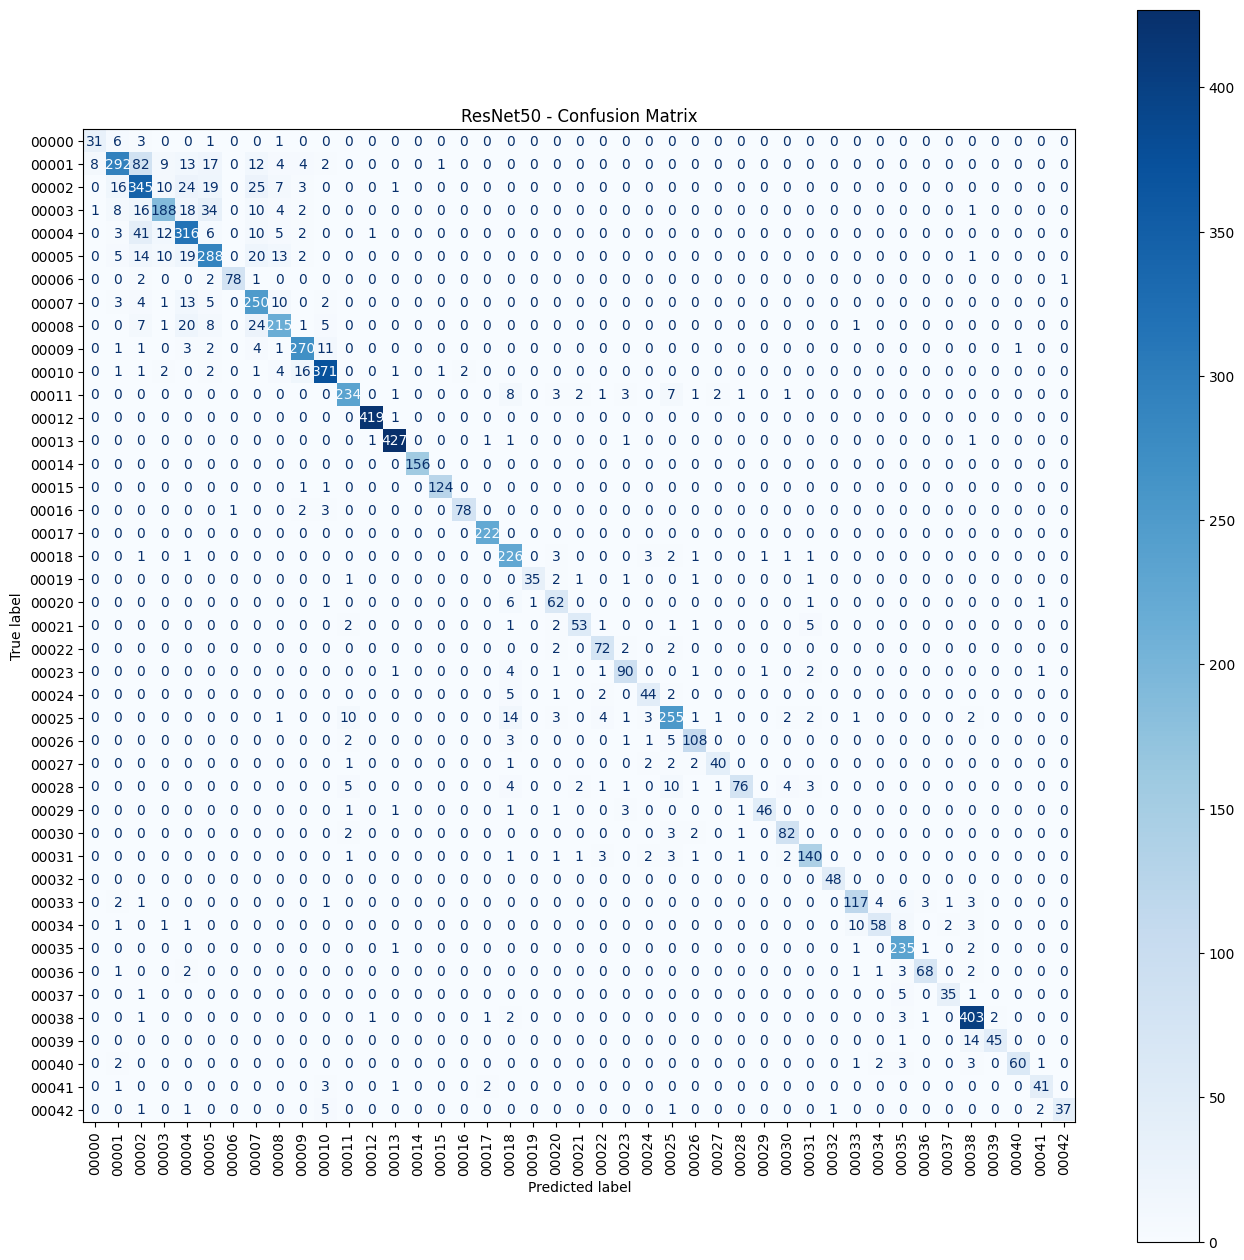

In [60]:
# ============================================================
# 19b. Vẽ và lưu Confusion Matrix
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    display_labels=target_names, 
    cmap='Blues', 
    xticks_rotation='vertical',
    ax=ax
)
plt.title("ResNet50 - Confusion Matrix")

os.makedirs(os.path.join(BASE_DIR, "assets"), exist_ok=True)
cm_path = os.path.join(BASE_DIR, "assets", "confusion_matrix_resnet.png")
plt.savefig(cm_path, bbox_inches='tight')
print(f"Đã lưu confusion matrix: {cm_path}")

plt.show()

In [61]:
# ============================================================
# 20. Tóm tắt kết quả phục vụ so sánh với ViT
# ============================================================

model_size_mb = os.path.getsize(RESNET_BEST_PATH) / (1024 * 1024) if os.path.exists(RESNET_BEST_PATH) else None
avg_epoch_time = float(np.mean(history_df["epoch_time_sec"])) if len(history_df) > 0 else None

resnet_summary = {
    "model": "ResNet50",
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_loss": float(val_loss),
    "final_val_acc": float(val_acc),
    "avg_epoch_time_sec": avg_epoch_time,
    "best_checkpoint_size_mb": float(model_size_mb) if model_size_mb is not None else None,
    "best_checkpoint_path": RESNET_BEST_PATH,
    "resume_checkpoint_path": RESNET_RESUME_PATH,
    "history_csv_path": HISTORY_CSV_PATH,
    "classification_report_path": REPORT_TXT_PATH
}

with open(SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(resnet_summary, f, ensure_ascii=False, indent=4)

print("===== RESNET50 SUMMARY =====")
for key, value in resnet_summary.items():
    print(f"{key}: {value}")

print("\nĐã lưu summary:", SUMMARY_JSON_PATH)


===== RESNET50 SUMMARY =====
model: ResNet50
epochs: 15
best_epoch: 12
best_val_acc: 0.864575363427697
final_val_loss: 0.43793927885932116
final_val_acc: 0.864575363427697
avg_epoch_time_sec: 144.36645007133484
best_checkpoint_size_mb: 90.99267101287842
best_checkpoint_path: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\checkpoints\resnet50_best.pth
resume_checkpoint_path: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\checkpoints\resnet50_resume.pth
history_csv_path: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\history\history_resnet.csv
classification_report_path: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\history\classification_report_resnet.txt

Đã lưu summary: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\history\summary_resnet.json


In [62]:
# ============================================================
# Lưu cấu hình thí nghiệm ResNet50
# ============================================================

CONFIG_DIR = os.path.join(BASE_DIR, "configs")
os.makedirs(CONFIG_DIR, exist_ok=True)

RESNET_CONFIG_PATH = os.path.join(CONFIG_DIR, "resnet50_config.json")

resnet50_config = {
    "section": "Section 2",
    "model_name": "ResNet50",
    "task": "GTSRB Traffic Sign Classification",
    "num_classes": NUM_CLASSES,

    "base_dir": BASE_DIR,
    "train_csv": TRAIN_CSV,
    "val_csv": VAL_CSV,
    "class_mapping_path": CLASS_MAPPING_PATH,

    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss",

    "pretrained_weights": "ResNet50_Weights.DEFAULT",
    "transfer_learning": True,
    "freeze_backbone": True,
    "trainable_layer": "fc",

    "train_transform": {
        "Resize": [IMG_SIZE, IMG_SIZE],
        "RandomRotation": 15,
        "ColorJitter": {
            "brightness": 0.2,
            "contrast": 0.2
        },
        "Normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        }
    },

    "val_transform": {
        "Resize": [IMG_SIZE, IMG_SIZE],
        "Normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        }
    },

    "checkpoint_paths": {
        "best": RESNET_BEST_PATH,
        "last": RESNET_LAST_PATH,
        "resume": RESNET_RESUME_PATH
    },

    "history_paths": {
        "history_csv": HISTORY_CSV_PATH,
        "history_json": HISTORY_JSON_PATH,
        "classification_report": REPORT_TXT_PATH,
        "summary": SUMMARY_JSON_PATH
    },

    "device": str(device),
    "seed": SEED
}

with open(RESNET_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(resnet50_config, f, ensure_ascii=False, indent=4)

print("Đã lưu ResNet50 config tại:", RESNET_CONFIG_PATH)

Đã lưu ResNet50 config tại: c:\Users\pct2k\Downloads\DL\GTSRB-DeepLearning-Classification\configs\resnet50_config.json


In [63]:
import pandas as pd
import json
import os

# Dùng BASE_DIR đã được cấu hình ở cell 3
history_path = os.path.join(BASE_DIR, "history", "history_resnet.csv")
summary_path = os.path.join(BASE_DIR, "history", "summary_resnet.json")
report_path = os.path.join(BASE_DIR, "history", "classification_report_resnet.txt")

history = pd.read_csv(history_path)
print(history.to_string())

with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

print(json.dumps(summary, ensure_ascii=False, indent=4))

    epoch  train_loss  train_acc  val_loss   val_acc  epoch_time_sec
0       1    1.711973   0.564128  1.141797  0.711553      148.807205
1       2    0.978206   0.736220  0.883994  0.775822      145.432719
2       3    0.780276   0.787260  0.717519  0.803239      146.097445
3       4    0.670524   0.812956  0.652648  0.818286      143.470391
4       5    0.607255   0.824688  0.569056  0.842515      144.968559
5       6    0.558783   0.838907  0.533817  0.842260      143.238104
6       7    0.520264   0.845060  0.489081  0.854501      143.250212
7       8    0.491630   0.852807  0.496021  0.852971      143.242771
8       9    0.468872   0.858482  0.463907  0.857052      140.722703
9      10    0.450439   0.863933  0.442425  0.863173      144.351589
10     11    0.411385   0.875315  0.455603  0.862408      145.185825
11     12    0.399185   0.878599  0.437900  0.864575      143.119339
12     13    0.390243   0.879427  0.443320  0.859347      145.799392
13     14    0.344441   0.899162  